# (06) paint w/ diff stride

**Motivation**: host = ```yoru```, device = ```cuda:0``` <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Load model

In [3]:
### k = 256
# a = 'poisson_Kyoto32-wht_t-16_b-8_k-256_m-8_s-3_<ngd|lin>'
# b = 'b100-ep1700-lr(0.001)_temp(0.05)_gr(200)_ConvPhi:SpaceBroadcast_(2025_06_25,21:01)'


### k = 512
a = 'poisson_Kyoto16-wht_t-32_b-8_k-512_m-1_<ngd|lin>'
b = 'b100-ep600-lr(0.001)_temp(0.05)_gr(200)_(2025_07_06,17:41)'


### load tr
tr, meta = load_model(pjoin(a, b), device)
meta['checkpoint']

600

### sanity check

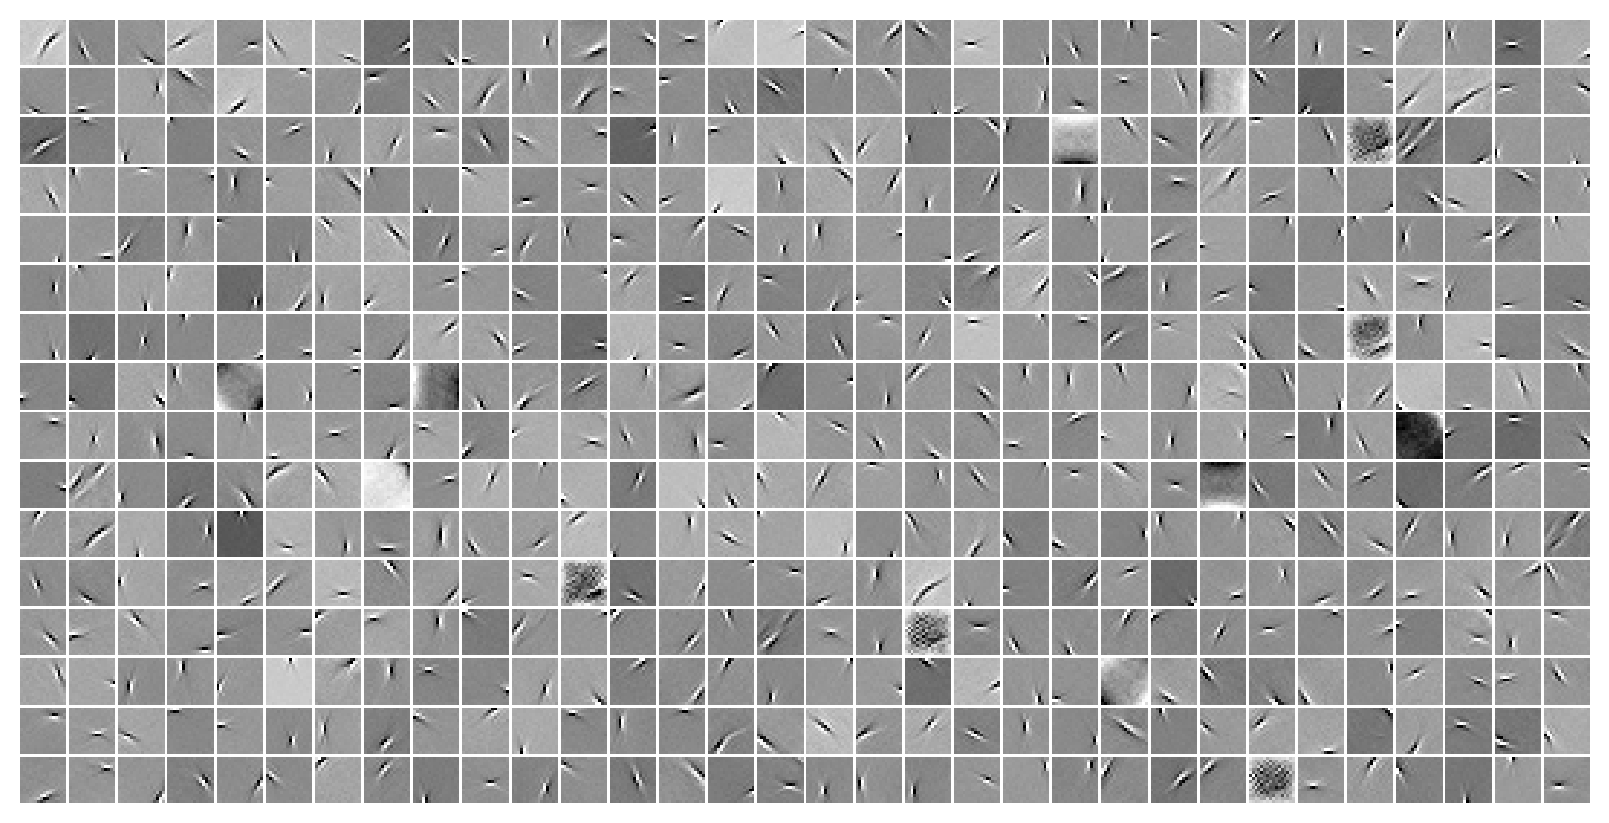

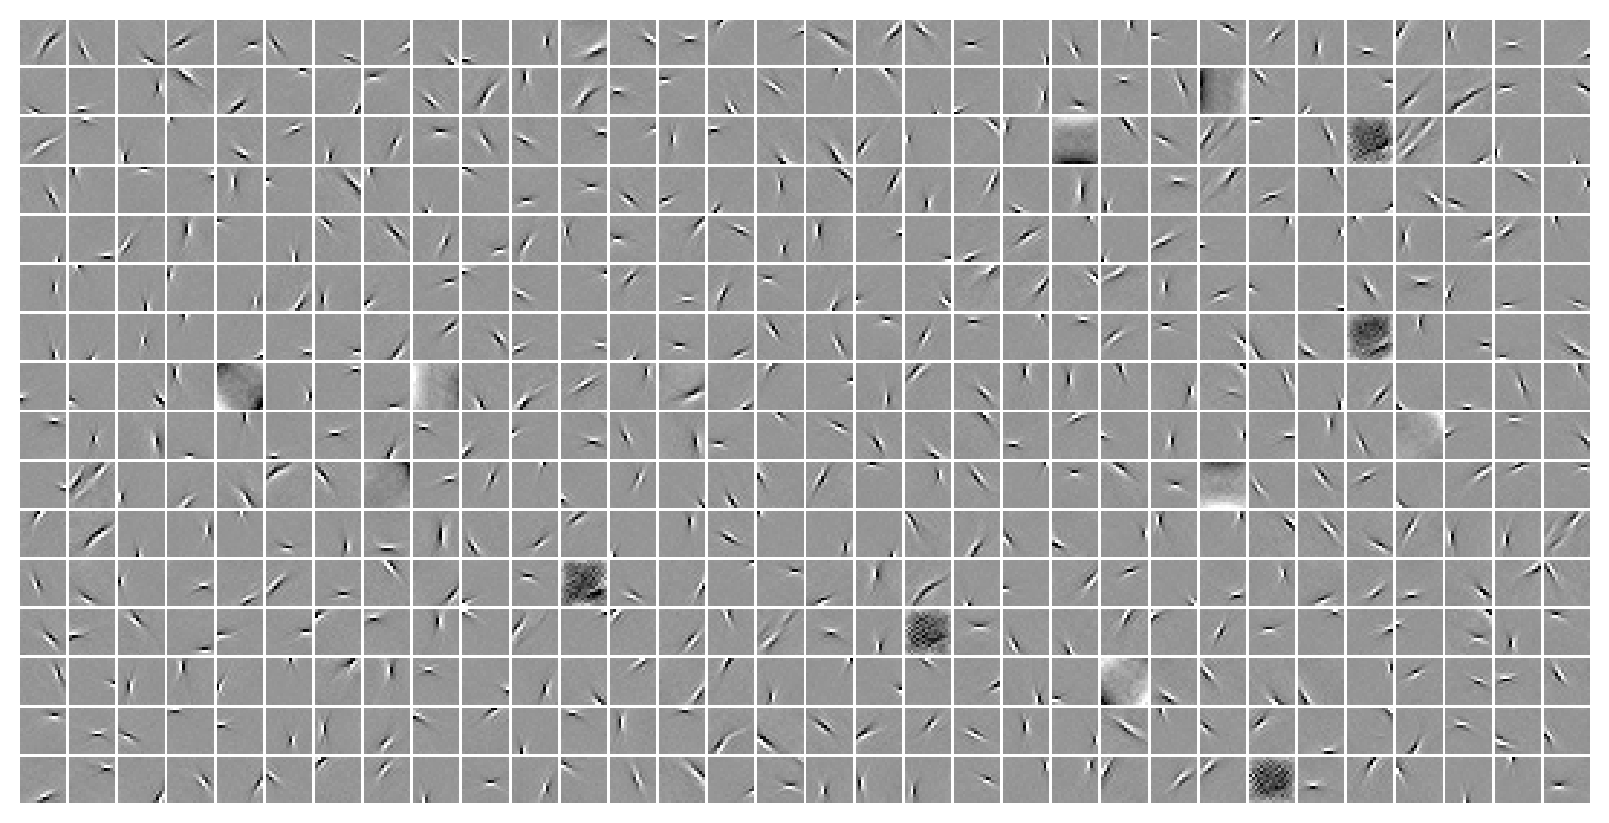

In [4]:
tr.model.show();
tr.model.show(method='abs-max');

100%|█████████████████████████████████| 10/10 [00:44<00:00,  4.41s/it]


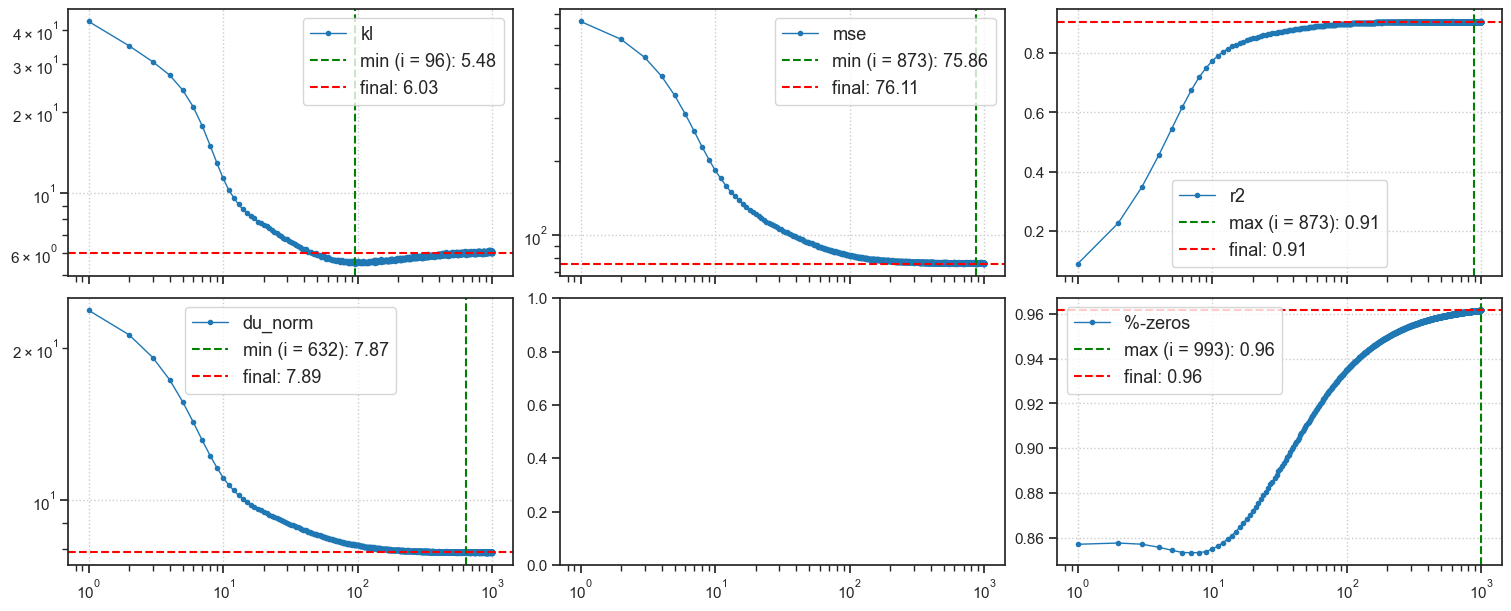

CPU times: user 1min, sys: 35.9 s, total: 1min 36s
Wall time: 1min 36s


In [5]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=10,
    compute_sprs=False,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='C0')

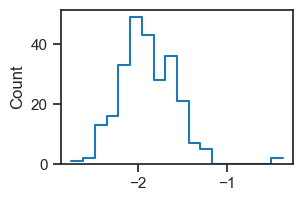

In [6]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
histplot(u0)
plt.show()

## Load Kyoto image

In [5]:
# root directory
root = 'Datasets/Kyoto/processed'
root = add_home(root)

# load bw
bw = np.load(pjoin(root, 'kyoto_bnw.npy'))
bw.shape

(62, 500, 500)

In [6]:
from utils.imgproc import do_process, Whitening

In [7]:
wht, *_ = do_process(tr.to(bw).unsqueeze(1), device=device, crop_size=0)
wht_shift_rescale = (wht - wht.mean()) / wht.std()
wht_shift_rescale *= tr.dl_trn.dataset.tensors[0].std()
wht_shift_rescale = tr.to(wht_shift_rescale)
wht_shift_rescale.shape

torch.Size([62, 1, 500, 500])

In [8]:
# change num latent pixels to accomodate new stim dim

tr.model.update_model_dims(
    new_stim_dim=wht_shift_rescale.shape[-1],
    new_stride=2,
)


# reduce u0 to very negative values

tr.model.layer.u_init[0].data.fill_(-7.0);

In [9]:
print(tr.model.layer.dec)

ConvDictionary(in_channels=512, out_channels=1, kernel_size=16, stride=2)

In [10]:
tr.model.layer.dec.output_padding

0

In [11]:
## TODO: temporary

wht_shift_rescale = wht_shift_rescale[[58, 59]]
wht_shift_rescale.shape

torch.Size([2, 1, 500, 500])

## stimulus presentation

In [12]:
crop = 5

n_frames_gray = 30
n_frames_stim = 300
t_total = n_frames_gray + n_frames_stim

gray_screen = torch.zeros_like(wht_shift_rescale)

items = [
    'state', 'samples',
    'recon', 'r2', 'mse',
]

all_lamb = []
all_spks = []
all_recon = []

r2 = np_nans((len(wht_shift_rescale), t_total))
mse_perdim = np_nans((len(wht_shift_rescale), t_total))
portion_zeros = np_nans((len(wht_shift_rescale), t_total))

tr.model.eval()

for t in tqdm(range(n_frames_gray + n_frames_stim)):
    # set current time
    tr.model.update_time(t)
    
    # select current stimulus
    if t < n_frames_gray:
        current_frame = gray_screen
    else:
        current_frame = wht_shift_rescale
    
    # xtract ftrs
    output = tr.model.xtract_ftr(
        x=current_frame,
        return_extras=items,
    )

    # process: recon, mean firing rates & spike counts
    _lamb = tonp(torch.exp(output['state'][0]).mean(-3))
    _spks = tonp(output['samples'].mean(-3))
    all_lamb.append(_lamb[:, crop:-crop, crop:-crop])
    all_spks.append(_spks[:, crop:-crop, crop:-crop])
    all_recon.append(tonp(output['recon'].squeeze()))

    # save scores, r2, mse, sparsity
    r2[:, t] = tonp(output['r2'])
    mse_perdim[:, t] = (
        1000 * tonp(output['mse']) /
        np.prod(tr.model.cfg.input_sz)
    )
    portion_zeros[:, t] = tonp(torch.mean(
        (output['samples'] == 0).float(),
        dim=(1, 2, 3),
    ))

# stack into arrays
all_lamb = np.stack(all_lamb, axis=1)
all_spks = np.stack(all_spks, axis=1)
all_recon = np.stack(all_recon, axis=1)

all_lamb.shape, all_spks.shape, all_recon.shape

100%|█████████████████████████████████████████| 330/330 [00:08<00:00, 37.96it/s]


((2, 330, 233, 233), (2, 330, 233, 233), (2, 330, 500, 500))

In [13]:
img_idx = 0  # 58

r2[img_idx][-1]

0.8963019847869873

In [14]:
img = tonp(wht_shift_rescale[img_idx].squeeze())
vminmax = np.quantile(np.abs(img), q=0.97)
kws_img = dict(
    vmin=-vminmax,
    vmax=vminmax,
    cmap='Greys_r',
)

kws_lamb = dict(
    vmin=0.0,
    vmax=np.quantile(all_lamb, q=0.99),
    cmap='Spectral_r',
)
kws_spks = dict(
    vmin=0.0,
    vmax=np.quantile(all_spks, q=0.99),
    cmap='Spectral_r',
)


In [15]:
kws_img

{'vmin': -0.9852669364213943, 'vmax': 0.9852669364213943, 'cmap': 'Greys_r'}

In [16]:
kws_lamb

{'vmin': 0.0, 'vmax': 0.02574332885444164, 'cmap': 'Spectral_r'}

In [17]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Create figure
fig, axes = create_figure(2, 2, (8.9, 7.6))

# Initialize plots
ims = []
ims.append(axes[0, 0].imshow(all_lamb[img_idx, 0], **kws_lamb))
ims.append(axes[0, 1].imshow(all_spks[img_idx, 0], **kws_spks))
ims.append(axes[1, 0].imshow(all_recon[img_idx, 0], **kws_img))
ims.append(axes[1, 1].imshow(np.zeros_like(img), **kws_img))

# Add titles
current_r2 = max(0.0, r2[img_idx, 0]) * 100
current_percent_active = (1 - portion_zeros[img_idx, 0]) * 100
axes[0, 0].set_title(f'firing rates (avg across {tr.model.cfg.latent_channels} neurons)')
axes[0, 1].set_title(f'spike counts (avg) — active: {current_percent_active:0.1f} %')
axes[1, 0].set_title(f'reconstructed img — r2: {current_r2:0.1f} %')
axes[1, 1].set_title('input img')
title_2 = axes[0, 1].title
title_3 = axes[1, 0].title
title_4 = axes[1, 1].title

# Add colorbars
plt.colorbar(ims[0], ax=axes[0, 0], location='left')
plt.colorbar(ims[1], ax=axes[0, 1])
plt.colorbar(ims[2], ax=axes[1, 0], location='left')
plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1])
remove_ticks(axes, False)

# Animation function
def animate(time_idx):
    ims[0].set_data(all_lamb[img_idx, time_idx])
    ims[1].set_data(all_spks[img_idx, time_idx])
    ims[2].set_data(all_recon[img_idx, time_idx])

    # Update dynamic titles
    current_r2 = max(0.0, r2[img_idx, time_idx]) * 100
    current_percent_active = (1 - portion_zeros[img_idx, time_idx]) * 100
    title_2.set_text(f'spike counts (avg) — active: {current_percent_active:0.1f} %')
    title_3.set_text(f'reconstructed img — r2: {current_r2:0.1f} %')

    # Update input image and title color
    if time_idx < n_frames_gray:
        ims[3].set_data(np.zeros_like(img))
        title_4.set_color('black')
    else:
        ims[3].set_data(img)
        title_4.set_color('red')

    return ims + [title_2, title_3, title_4]

# Create animation
anim = animation.FuncAnimation(
    fig=fig,
    func=animate,
    frames=t_total,
    interval=100,
    blit=True,
)

# Save as MP4
fname = '_'.join([
    f"z-{str(tr.model.cfg.latent_sz).replace(' ', '')}",
    f"s-{tr.model.cfg.latent_stride}",
    f"kyoto-{img_idx}",
])
anim.save(f'{fname}.mp4', writer='ffmpeg', fps=10, dpi=150)
plt.close()

In [18]:
fig, ax = create_figure()
ax.plot(r2[img_idx])
ax.set(ylim=(0, 1))

[(0.0, 1.0)]

In [19]:
fig, ax = create_figure()
ax.plot(mse_perdim[img_idx])
#ax.set(ylim=(0, 1))

In [20]:
r2[img_idx][-1]

0.8963019847869873